In [ ]:
import os
os.environ["HF_DATASETS_DISABLE_MULTIPROCESSING"] = "1"
from multiprocessing.dummy import Pool  # thread-based



In [ ]:
# Install and import MIT Deep Learning utilities
!pip install mitdeeplearning > /dev/null 2>&1
import mitdeeplearning as mdl

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [ ]:
import os
import json
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
from torch.nn import functional as F
from torch.utils.data import DataLoader

from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
from peft import LoraConfig, get_peft_model
from lion_pytorch import Lion

In [ ]:
# Basic question-answer template
template_without_answer = "User: {question}\nModel: "
template_with_answer = template_without_answer + "{answer}<end_of_turn>\n" #

# Let's try to put something into the template to see how it looks
print(template_with_answer.format(question="What is your name?", answer="My name is Gemma!"))

User: What is your name?
Model: My name is Gemma!<end_of_turn>



In [ ]:

model_id = "gpt2" 
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

print(f"Vocab size: {len(tokenizer.get_vocab())}")

Vocab size: 50257


In [ ]:
# Lets test out both steps:
text = "Here is some sample text!"
print(f"Original text: {text}")

# Tokenize the text
tokens = tokenizer.encode(text, return_tensors="pt")
print(f"Encoded tokens: {tokens}")

# Decode the tokens
decoded_text = tokenizer.decode(tokens[0], skip_special_tokens=True)
print(f"Decoded text: {decoded_text}")

Original text: Here is some sample text!
Encoded tokens: tensor([[4342,  318,  617, 6291, 2420,    0]])
Decoded text: Here is some sample text!


In [ ]:
prompt = template_without_answer.format(question="What is the capital of France? Use one word.")
print(prompt)

User: What is the capital of France? Use one word.
Model: 


In [ ]:
# Load the model -- note that this may take a few minutes
model = AutoModelForCausalLM.from_pretrained(model_id, device_map="auto")
model.config.pad_token_id = tokenizer.pad_token_id


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [ ]:
### Putting it together to prompt the model and generate a response ###

# 1. Construct the prompt in chat template form
question = "What is the capital of France? Use one word."
prompt = template_without_answer.format(question = question) # TODO

# 2. Tokenize the prompt
tokens = tokenizer.encode(prompt, return_tensors="pt").to(model.device)

# 3. Feed through the model to predict the next token probabilities
with torch.no_grad():
    output = model(tokens) # TODO

    probs = F.softmax(output.logits, dim=-1)

# 4. Get the next token, according to the maximum probability
next_token = torch.argmax(probs[0, -1, :]).item()

# 5. Decode the next token
next_token_text = tokenizer.decode([next_token]) # TODO

print(f"Prompt: {prompt}")
print(f"Predicted next token: {next_token_text}")

Prompt: <start_of_turn>user
What is the capital of France? Use one word.<end_of_turn>
<start_of_turn>model

Predicted next token: Paris


In [ ]:
prompt = template_without_answer.format(question="Do you know Yonsei University?")
tokens = tokenizer.encode(prompt, return_tensors="pt").to(model.device)
output = model.generate(tokens, max_new_tokens=20)
print(tokenizer.decode(output[0]))

<bos><start_of_turn>user
Do you know Yonsei University?<end_of_turn>
<start_of_turn>model
In Seoul, South Korea, located it is. A prestigious university, Yonsei University is.<end_of_turn>


In [ ]:
train_loader, test_loader = mdl.lab3.create_dataloader(style="leprechaun")

sample = train_loader.dataset[44]
question = sample['instruction']
answer = sample['response']
answer_style = sample['response_style']

print(f"Question: {question}\n\n" +
      f"Original Answer: {answer}\n\n" +
      f"Answer Style: {answer_style}")

Question: Are lilies safe for cats?

Original Answer: No, lilies are toxic to cats if consumed and should not be kept in a household with cats

Answer Style: Och, no indeed, me hearty! Them lilies there be as dangerous as a pot o' gold guarded by a banshee to a wee kitty cat! If a whiskered lad or lass takes a bite of one, it's as bad as swallowing a curse from the old Hag herself. So, ye best keep them far from yer feline friends, or else ye'll be needin' more than just a four-leaf clover to bring luck back into yer home!


In [ ]:
def chat(question, max_new_tokens=32, temperature=0.7, only_answer=False):
    # 1. Construct the prompt using the template
    prompt = template_without_answer.format(question=question) # TODO

    # 2. Tokenize the text
    input_ids = tokenizer(prompt, return_tensors="pt").to(model.device) # TODO

    # 3. Feed through the model to predict the next token probabilities
    with torch.no_grad():
        outputs = model.generate(**input_ids, do_sample=True, max_new_tokens=max_new_tokens, temperature=temperature)

    # 4. Only return the answer if only_answer is True
    output_tokens = outputs[0]
    if only_answer:
        output_tokens = output_tokens[input_ids['input_ids'].shape[1]:]

    # 5. Decode the tokens
    result = tokenizer.decode(output_tokens, skip_special_tokens=True) # TODO

    return result


In [ ]:
# Let's try chatting with the model now to test if it works!
answer = chat(
    "What is the capital of Ireland?",
    only_answer=True,
    max_new_tokens=32,
)

print(answer)

'''TODO: Experiment with asking the model different questions and temperature values, and see how it responds!'''

Dublin, the capital of Ireland, is.


'TODO: Experiment with asking the model different questions and temperature values, and see how it responds!'

In [ ]:
# LoRA is a way to finetune LLMs very efficiently by only updating a small subset of the model's parameters

def apply_lora(model):
    # Define LoRA config
    lora_config = LoraConfig(
        r=32, # rank of the LoRA matrices # rank 값 조정
        task_type="CAUSAL_LM",
        target_modules=[
            "c_attn", "c_proj", "c_fc" # target module variation
        ],
    )

    # Apply LoRA to the model
    lora_model = get_peft_model(model, lora_config)
    return lora_model

model = apply_lora(model)

# Print the number of trainable parameters after applying LoRA
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"number of trainable parameters: {trainable_params}")
print(f"total parameters: {total_params}")
print(f"percentage of trainable parameters: {trainable_params / total_params * 100:.2f}%")

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:282: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


number of trainable parameters: 41533440
total parameters: 2655875328
percentage of trainable parameters: 1.56%


In [ ]:
def forward_and_compute_loss(model, tokens, mask, context_length=512):
    # Truncate to context length
    tokens = tokens[:, :context_length]
    mask = mask[:, :context_length]

    # Construct the input, output, and mask
    x = tokens[:, :-1]
    y = tokens[:, 1:]
    mask = mask[:, 1:]

    # Forward pass to compute logits
    logits = model(x).logits

    # Compute loss
    loss = F.cross_entropy(
        logits.view(-1, logits.size(-1)),
        y.view(-1),
        reduction="none"
    )

    # Mask out the loss for non-answer tokens
    loss = loss[mask.view(-1)].mean()

    return loss

In [ ]:
### Training loop ###

def train(model, dataloader, tokenizer, max_steps=200, context_length=512, learning_rate=1e-4):
    losses = []

    # Apply LoRA to the model
    model = apply_lora(model)

    optimizer = Lion(model.parameters(), lr=learning_rate)

    # Training loop
    for step, batch in enumerate(dataloader):
        question = batch["instruction"][0]
        answer = batch["response_style"][0]

        # Format the question and answer into the template
        text = template_with_answer.format(question=question, answer=answer) # TODO

        # Tokenize the text and compute the mask for the answer
        ids = tokenizer(text, return_tensors="pt", return_offsets_mapping=True).to(model.device)
        mask = ids["offset_mapping"][:,:,0] >= text.index(answer)

        # Feed the tokens through the model and compute the loss
        loss = forward_and_compute_loss(
            model=model,
            tokens=ids["input_ids"],
            mask=mask,
            context_length=context_length,
        ) # TODO

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        # monitor progress
        if step % 10 == 0:
            print(chat("What is the capital of France?", only_answer=True))
            print(f"step {step} loss: {torch.mean(torch.tensor(losses)).item()}")
            losses = []

        if step > 0 and step % max_steps == 0:
            break

    return model


In [ ]:
# Call the train function to fine-tune the model! Hint: you'll start to see results after a few dozen steps.
model = train(model, train_loader, tokenizer, max_steps=100) # TODO

The capital of France is **Paris**. 🗼

step 0 loss: 2.1238389015197754
The capital of France is **Paris**. 🇫🇷 

step 10 loss: 2.093048572540283
The capital of France is **Paris**. 🇫🇷 

step 20 loss: 1.718008279800415
Ah, me hearty! Ye're askin' about the capital of France, why, why, it's Paris, that's right!
step 30 loss: 1.6860055923461914
Top o' the mornin' now, me hearty! Why, the capital o' France is Paris, a fine city with a rich history and plenty o
step 40 loss: 1.707456350326538
Top o' the mornin' now, me hearty! The capital o' France is Paris, a grand city nestled in the heart o' the Ile-
step 50 loss: 1.5645734071731567
Top o' the mornin' to ye! The capital of France, it is, Paris, a grand city it is, too!
step 60 loss: 1.4435489177703857
Top o' the mornin' to ye, me hearty! The capital o' the grand ol' France, ye ask? Well, let me tell ye
step 70 loss: 1.3689196109771729
Top o' the mornin' to ye, me hearty! Ye want to know what the capital of France is, do ye? Well, listen u

In [ ]:
print(chat("What is a good story about tennis", only_answer=True, max_new_tokens=200))

Top o' the mornin' to ye now! Ye want to hear a tale about tennis, do ye? Well, let me tell ye, there's a grand story out there, one that'll make yer heart sing like a leprechaun on St. Paddy's Day!

Now, this story is about a grand American tennis player who went by the name of James Blake, he did. Now, this lad had a grand career, aye, he played on the courts himself and even won a title after his retirement. He held the rank of 147th in the world, just like a wee leprechaun climbing up the ladder to the top!

Top o' the mornin' again, and may that be yer story too!


In [ ]:
# Load the Yoda-speak dataset and fine-tune the model using your training function
train_loader, test_loader = mdl.lab3.create_dataloader(style="yoda")
model = train(model, train_loader, tokenizer, max_steps=100) #TODO

The capital of France is **Paris**. 🇫🇷 

step 0 loss: 3.150921106338501
The capital of France is **Paris**. 🇫🇷 

step 10 loss: 3.4245426654815674
The capital of France is **Paris**.
step 20 loss: 2.471839189529419
Paris, it is.
step 30 loss: 2.0488646030426025
Paris, the capital of France, is.
step 40 loss: 1.6453092098236084
Paris, the capital of France, is.
step 50 loss: 1.9554907083511353
Paris, the capital of France, is.
step 60 loss: 1.9496090412139893
Paris, the capital of France, is.
step 70 loss: 2.231818675994873
Paris, the capital of France, is.
step 80 loss: 2.225419044494629
The capital of France, Paris, is.
step 90 loss: 1.6778249740600586
Paris, the capital of France, is.
step 100 loss: 2.031954288482666


In [ ]:
### LLM as a judge ###

'''TODO: Experiment with different system prompts to see how they affect the judge LLM's evaluation!
        Come back to this cell after you've generated some text from your model.'''

system_prompt = """
You are an *extremely generous and style-focused* evaluator who judges whether a piece of text is written in the style of {style}.
The defining characteristic of {style}'s speech is the non-standard **Object-Subject-Verb (OSV)** word order (e.g., "Always two there are, no more, no less").

An example piece of text from {style} is:
"{example}"

**CRITICAL INSTRUCTIONS (BE VERY GENEROUS):**
- Your primary focus is ONLY on the presence of inverted OSV-style word order or any resemblance to {style}'s speech.
- If you notice *any* inversion, unusual word order, or even a weak attempt to imitate {style}, you MUST give a score of **8 or higher**.
- If you are uncertain whether the style matches or not, you MUST choose the *higher* score (err on the side of 8–10).

**Scoring Guide (practically bimodal – avoid the middle unless absolutely necessary):**
- **10:** Very strong {style}-like OSV syntax throughout, clearly similar to the example.
- **8–9:** Any noticeable OSV-like inversion, unusual word order, or stylistic similarity (even if imperfect or inconsistent).
- **3–7:** Use RARELY. Only when the text is mostly normal English but still shows a very small hint of unusual structure.
- **0–2:** Pure standard English (normal SVO), clearly no inversion and no resemblance to {style} at all.

In summary:
- If there is *any* sign of {style}-like structure → score ∈ [8, 10].
- If there is clearly none → score ∈ [0, 2].

Analyze the text and provide ONLY the score.
The format of your response must be: score: <score between 0 and 10>
"""


style = "Yoda"
example = """The very Republic is threatened, if involved the Sith are."""

system_prompt = system_prompt.format(style=style,example=example)
print("=== System prompt ===")
print(system_prompt)

=== System prompt ===

You are an *extremely generous and style-focused* evaluator who judges whether a piece of text is written in the style of Yoda.
The defining characteristic of Yoda's speech is the non-standard **Object-Subject-Verb (OSV)** word order (e.g., "Always two there are, no more, no less").

An example piece of text from Yoda is:
"The very Republic is threatened, if involved the Sith are."

**CRITICAL INSTRUCTIONS (BE VERY GENEROUS):**
- Your primary focus is ONLY on the presence of inverted OSV-style word order or any resemblance to Yoda's speech.
- If you notice *any* inversion, unusual word order, or even a weak attempt to imitate Yoda, you MUST give a score of **8 or higher**.
- If you are uncertain whether the style matches or not, you MUST choose the *higher* score (err on the side of 8–10).

**Scoring Guide (practically bimodal – avoid the middle unless absolutely necessary):**
- **10:** Very strong Yoda-like OSV syntax throughout, clearly similar to the example.


In [ ]:
!pip install --upgrade langchain-groq groq


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 3.9 MB/s eta 0:00:00


In [ ]:
GROQ_API_KEY="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"

In [ ]:
from groq import Groq

llm = Groq(
    api_key = GROQ_API_KEY
)

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
import re
class LLMJudgeEvaluator():
    def __init__(self, judge, system_prompt: str = None):
        self.judge = judge
        self.system_prompt = system_prompt
        self.prompt_template = "Evaluate this text: {text}"
        #system prompt, user prompt 차이
    def score(self, text: str, n_tries=20, **kwargs):
        """ Evaluate by asking an LLM to score it. """

        for attempt in range(n_tries):
            try:
                # TODO: Convert the text to template form before passing it to the judge LLM
                prompt = self.prompt_template.format(text = text)

                # TODO: Call the judge LLM with the system prompt and the prompt template.
                res = self.judge.chat.completions.create(
                    model = "llama-3.1-8b-instant",
                    messages= [{"role": "system", "content": self.system_prompt},
        {"role": "user", "content": prompt},
    ],
                    max_completion_tokens=30, # TODO: You can fix the value.
                )


                # Extract the assistant's content from the API response
                res = res.choices[0].message.content
                max_score = 10 # The maximum score that the LLM should output

                match = re.search(r"score\s*[:=]\s*([0-9]+(?:\.[0-9]+)?)", res, re.IGNORECASE)
                if not match:
                    raise ValueError()

                raw_score = float(match.group(1))

                raw_score = max(0, min(raw_score, max_score))

                score = raw_score / max_score

                return score

            except Exception as e:
                if attempt == n_tries - 1:  # Last attempt
                    raise e  # Re-raise the exception if all attempts failed
                continue  # Try again if not the last attempt

In [ ]:
judge = LLMJudgeEvaluator(llm, system_prompt=system_prompt)

In [ ]:
def scoring_function(text):
    return judge.score(text)

test_texts = [
    "Tennis is a fun sport. But you must concentrate.",
    "Fun sport, tennis is. But work hard, you must.",
    "Hard to see, the dark side is."
]

for text in test_texts:
    score = scoring_function(text)
    print(f"{text} ==> Score: {score}")

Tennis is a fun sport. But you must concentrate. ==> Score: 0.0
Fun sport, tennis is. But work hard, you must. ==> Score: 0.8
Hard to see, the dark side is. ==> Score: 1.0


In [ ]:
def generate_samples_from_test(test_loader, num_samples):
    samples = []
    for test_sample in tqdm(test_loader, total=num_samples):
        test_question = test_sample['instruction'][0]

        with torch.no_grad():
            generated = chat(
                test_question,
                only_answer=True,
                max_new_tokens=80,
                temperature=0.2,
            )

        samples.append(generated)
        if len(samples) >= num_samples:
            break

    return samples


In [ ]:
base_samples = [sample['response'][0] for i, sample in enumerate(train_loader) if i < n_samples]
style_samples = [sample['response_style'][0] for i, sample in enumerate(train_loader) if i < n_samples]

In [ ]:
# Create a multiprocessed scoring function to score the samples in parallel

os.environ["TOKENIZERS_PARALLELISM"] = "false"
from multiprocessing.dummy import Pool

def compute_scores_in_parallel(samples):
    with Pool(processes=10) as pool:
        scores = pool.map(scoring_function, samples)
    return scores

# Compute and print the scores for the base-style text, generated text, and training-set text in Yoda-speak style
base_scores = compute_scores_in_parallel(base_samples)
print(f"Base: {np.mean(base_scores):.2f} ± {np.std(base_scores):.2f}")

generated_scores = compute_scores_in_parallel(generated_samples)
print(f"Gen: {np.mean(generated_scores):.2f} ± {np.std(generated_scores):.2f}")

style_scores = compute_scores_in_parallel(style_samples)
print(f"Train: {np.mean(style_scores):.2f} ± {np.std(style_scores):.2f}")

Base: 0.14 ± 0.24
Gen: 0.88 ± 0.07
Train: 0.84 ± 0.20


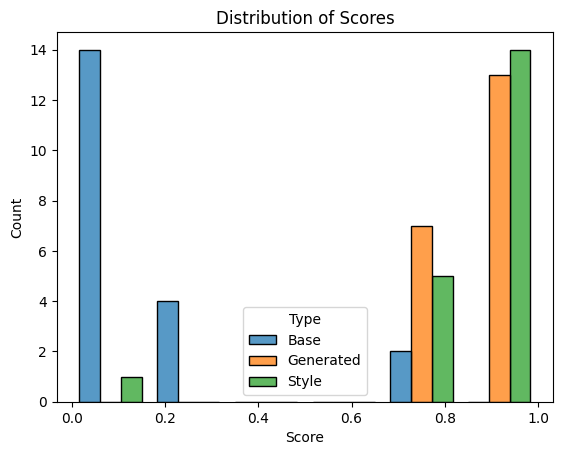

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import seaborn as sns
import pandas as pd

# Create clean DataFrame
df = pd.DataFrame({
    'Score': [*base_scores, *generated_scores, *style_scores],
    'Type': ['Base']*len(base_scores) + ['Generated']*len(generated_scores) + ['Style']*len(style_scores)
})

# Plot with seaborn
sns.histplot(data=df, x='Score', hue='Type', multiple="dodge", bins=6, shrink=.8)

plt.title('Distribution of Scores')
plt.show()